# Phase 8 & 9 — VaR Backtesting and Model Comparison
Runs the backtesting engine against all four VaR models (Historical, EWMA, GARCH, GJR-GARCH) and compares them. All logic lives in `src/backtesting/`, this notebook only calls it and shows results.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from src.data_collection import config
from src.data_collection.saver import save_processed
from src.var.historical import rolling_historical_var
from src.volatility.ewma import ewma_scaled_returns
from src.volatility.garch import fit_garch_model, garch_scaled_returns
from src.volatility.gjr_garch import fit_gjr_garch_model, gjr_garch_scaled_returns
from src.backtesting.exceptions import identify_exceptions, summarize_exceptions
from src.backtesting.report import run_backtest
from src.backtesting.comparison import compare_models, rank_models
from src.visualization import backtesting_charts

## Load Phase 3 output (portfolio returns)

In [2]:
portfolio_returns = pd.read_csv(
    config.DATA_PROCESSED_DIR / 'portfolio_returns_phase3.csv',
    index_col=0, parse_dates=True
).iloc[:, 0]
portfolio_returns.tail()

date
2026-07-16   -0.015001
2026-07-17   -0.014545
2026-07-20    0.001204
2026-07-21    0.011876
2026-07-22    0.006389
Name: portfolio_return, dtype: float64

## Build a rolling VaR series for each of the four models
Each uses a 250-day rolling window at 95% confidence, so all four are directly comparable on the same out-of-sample period.

In [3]:
WINDOW = 250
CONFIDENCE = 0.95

# 1. Plain Historical VaR
var_historical = rolling_historical_var(portfolio_returns, window=WINDOW, confidence_level=CONFIDENCE)

# 2. EWMA-scaled Historical VaR (rolling: scale each window's returns, then take historical VaR of that window)
def rolling_scaled_var(returns, scale_fn, window, confidence_level):
    from src.var.historical import calculate_historical_var
    result = pd.Series(index=returns.index, dtype=float)
    for i in range(window, len(returns) + 1):
        window_returns = returns.iloc[i - window:i]
        scaled = scale_fn(window_returns)
        result.iloc[i - 1] = calculate_historical_var(scaled, confidence_level)
    return result

var_ewma = rolling_scaled_var(portfolio_returns, ewma_scaled_returns, WINDOW, CONFIDENCE)
print('EWMA rolling VaR built.')

EWMA rolling VaR built.


In [4]:
# 3 & 4. GARCH and GJR-GARCH scaled VaR -- fit ONCE on full history (refitting per rolling
# window would be very slow) and use the in-sample conditional volatility path to scale.
# This is a reasonable simplification for this project's scope; production systems
# typically refit periodically (e.g. monthly) rather than either extreme.
garch_fitted = fit_garch_model(portfolio_returns)
gjr_fitted = fit_gjr_garch_model(portfolio_returns)

garch_scaled = garch_scaled_returns(portfolio_returns, garch_fitted)
gjr_scaled = gjr_garch_scaled_returns(portfolio_returns, gjr_fitted)

var_garch = rolling_historical_var(garch_scaled, window=WINDOW, confidence_level=CONFIDENCE)
var_gjr_garch = rolling_historical_var(gjr_scaled, window=WINDOW, confidence_level=CONFIDENCE)
print('GARCH and GJR-GARCH rolling VaR built.')

GARCH and GJR-GARCH rolling VaR built.


## Phase 8 — Backtest each model individually

In [5]:
var_by_model = {
    'Historical': var_historical,
    'EWMA': var_ewma,
    'GARCH': var_garch,
    'GJR-GARCH': var_gjr_garch,
}

backtest_reports = {name: run_backtest(portfolio_returns, var, CONFIDENCE) for name, var in var_by_model.items()}

for name, report in backtest_reports.items():
    print(f"{name}: {report.exception_summary.n_exceptions} exceptions "
          f"(expected {report.exception_summary.expected_exceptions:.1f}), "
          f"Kupiec p={report.kupiec.p_value:.4f}, Basel={report.basel.zone}, "
          f"Conclusion={report.overall_conclusion}")

Historical: 62 exceptions (expected 57.2), Kupiec p=0.5203, Basel=Green, Conclusion=Pass
EWMA: 56 exceptions (expected 57.2), Kupiec p=0.8703, Basel=Green, Conclusion=Pass
GARCH: 81 exceptions (expected 57.2), Kupiec p=0.0023, Basel=Yellow, Conclusion=Fail
GJR-GARCH: 78 exceptions (expected 57.2), Kupiec p=0.0074, Basel=Yellow, Conclusion=Fail


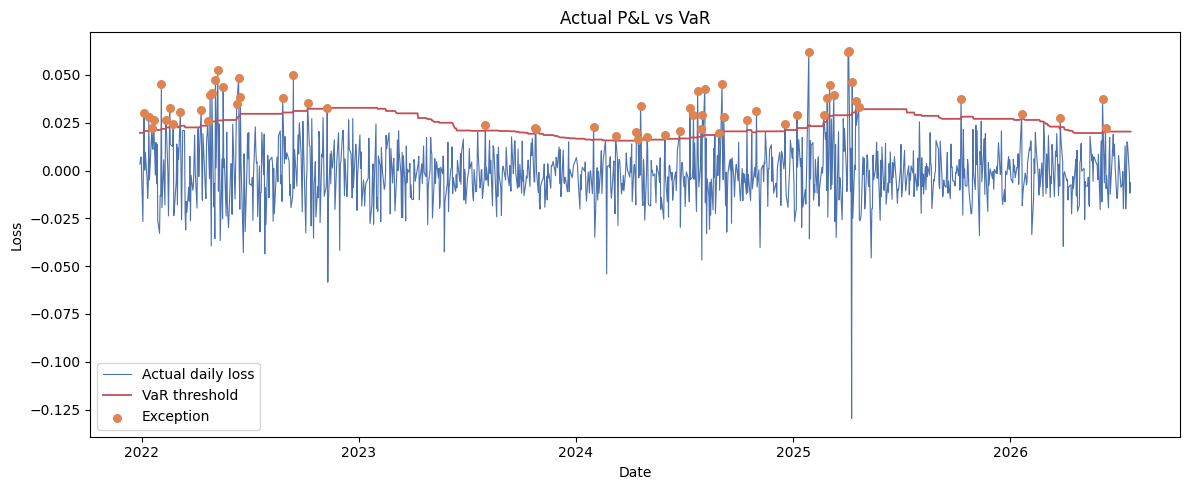

In [6]:
# Charts for the Historical model (repeat for others by changing the key)
hist_report = backtest_reports['Historical']
fig1 = backtesting_charts.plot_actual_pnl_vs_var(portfolio_returns, var_historical, hist_report.exceptions)
plt.show()

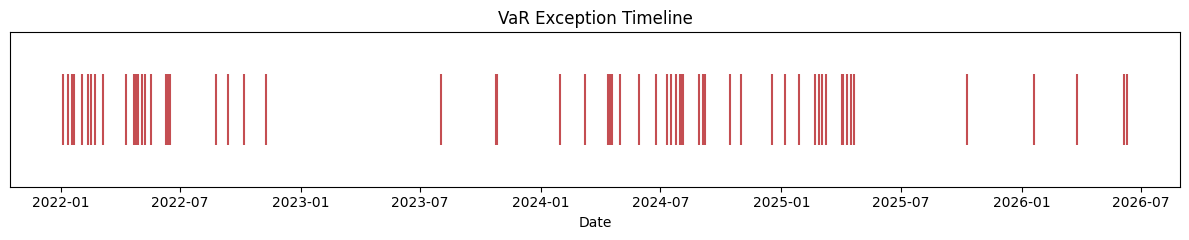

In [7]:
fig2 = backtesting_charts.plot_exception_timeline(hist_report.exceptions)
plt.show()

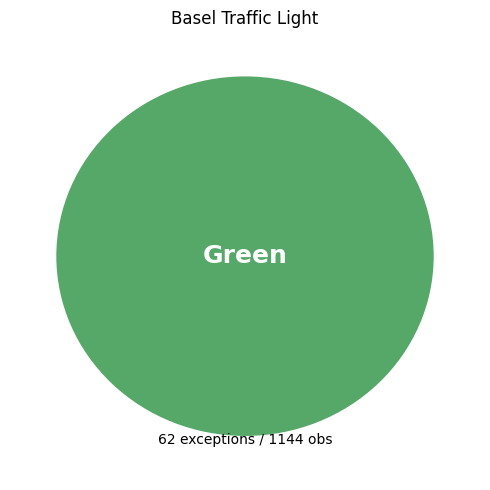

In [8]:
fig3 = backtesting_charts.plot_basel_traffic_light(hist_report.basel)
plt.show()

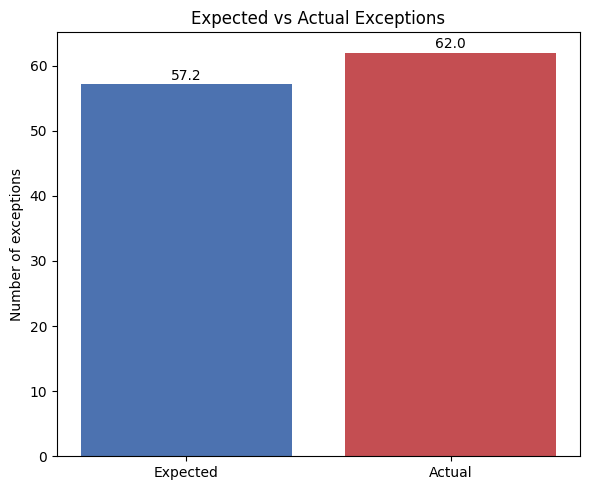

In [9]:
fig4 = backtesting_charts.plot_expected_vs_actual_exceptions(hist_report.exception_summary)
plt.show()

## Phase 9 — Compare all four models

In [10]:
comparison_table = compare_models(portfolio_returns, var_by_model, confidence_level=CONFIDENCE)
comparison_table

,n_exceptions,exception_ratio,expected_ratio,average_var,var_volatility,worst_daily_loss,expected_shortfall,kupiec_p_value,christoffersen_p_value,basel_zone,overall_conclusion
model,,,,,,,,,,,
Historical,62,0.054196,0.05,0.024175,0.005370,0.062639,0.035288,0.520344,0.720577,Green,Pass
EWMA,56,0.048951,0.05,0.024805,0.009916,0.062639,0.035288,0.870257,0.621372,Green,Pass
GARCH,81,0.070804,0.05,0.021446,0.002649,0.062639,0.035288,0.002312,0.907661,Yellow,Fail
GJR-GARCH,78,0.068182,0.05,0.021688,0.002324,0.062639,0.035288,0.007352,0.453789,Yellow,Fail


In [11]:
ranked = rank_models(comparison_table)
ranked

,rank,n_exceptions,exception_ratio,expected_ratio,average_var,var_volatility,worst_daily_loss,expected_shortfall,kupiec_p_value,christoffersen_p_value,basel_zone,overall_conclusion
model,,,,,,,,,,,,
EWMA,1,56,0.048951,0.05,0.024805,0.009916,0.062639,0.035288,0.870257,0.621372,Green,Pass
Historical,2,62,0.054196,0.05,0.024175,0.005370,0.062639,0.035288,0.520344,0.720577,Green,Pass
GJR-GARCH,3,78,0.068182,0.05,0.021688,0.002324,0.062639,0.035288,0.007352,0.453789,Yellow,Fail
GARCH,4,81,0.070804,0.05,0.021446,0.002649,0.062639,0.035288,0.002312,0.907661,Yellow,Fail


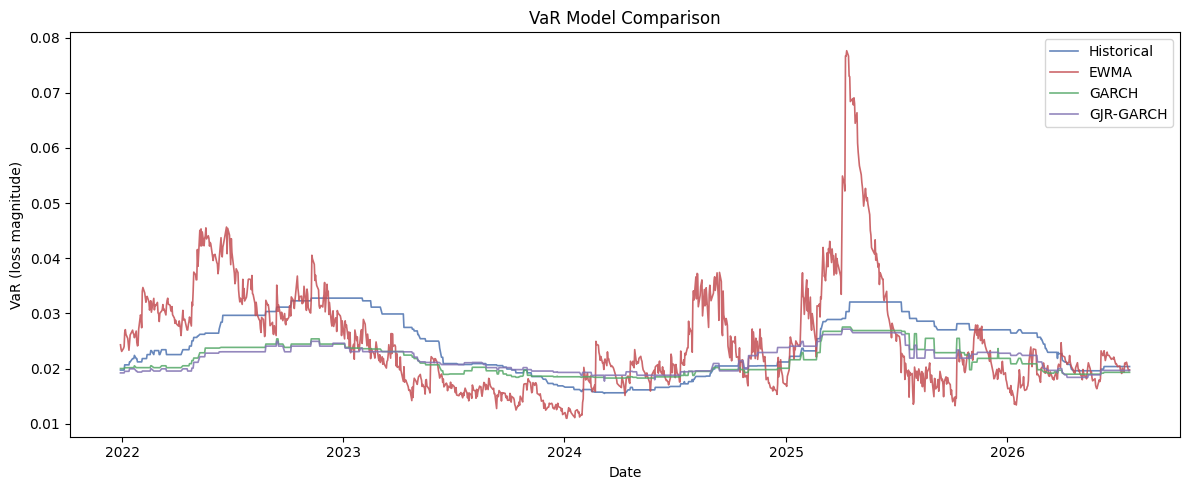

In [12]:
fig5 = backtesting_charts.plot_var_model_comparison(var_by_model)
plt.show()

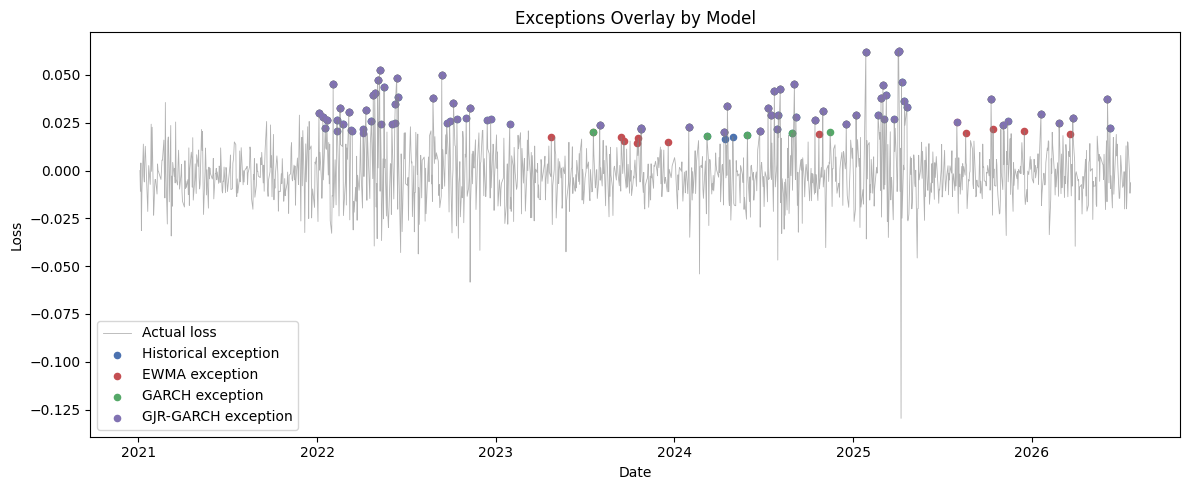

In [13]:
fig6 = backtesting_charts.plot_exceptions_overlay(portfolio_returns, var_by_model)
plt.show()

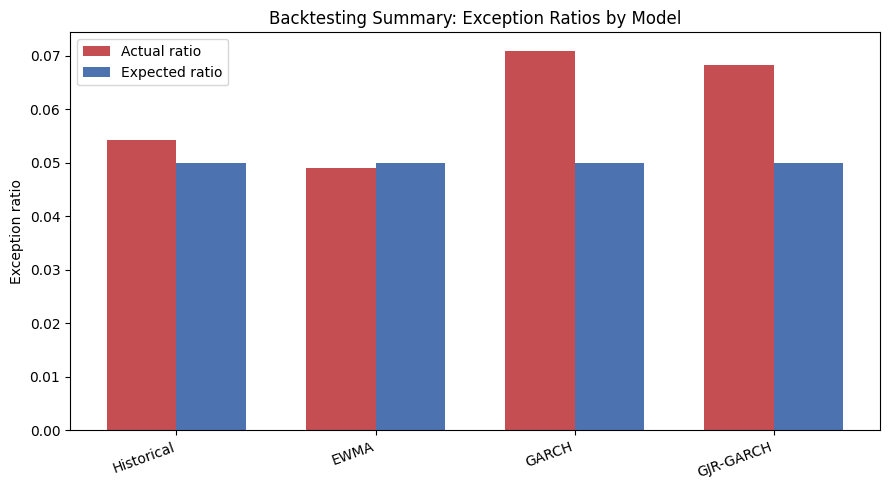

In [14]:
fig7 = backtesting_charts.plot_backtesting_summary_bar(comparison_table)
plt.show()

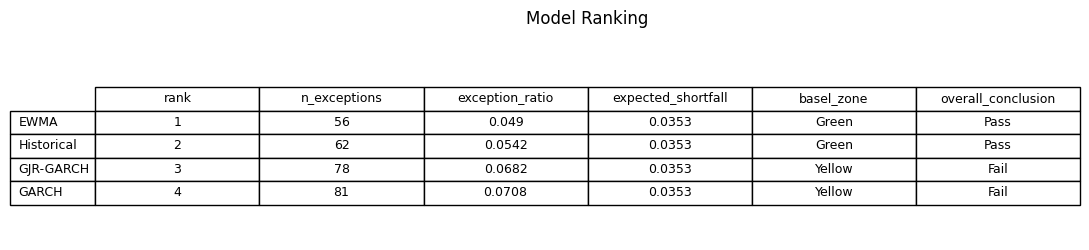

In [15]:
fig8 = backtesting_charts.plot_model_ranking_table(ranked)
plt.show()

## Save Phase 8 & 9 outputs

In [16]:
save_processed(comparison_table, 'model_comparison_table.csv', config.DATA_PROCESSED_DIR)
save_processed(ranked, 'model_ranking.csv', config.DATA_PROCESSED_DIR)
for name, var in var_by_model.items():
    save_processed(var.to_frame(), f'rolling_var_{name.lower().replace("-", "_")}.csv', config.DATA_PROCESSED_DIR)
print('Phase 8 & 9 outputs saved.')

Phase 8 & 9 outputs saved.
